# Notebook 02 - Exploratory Data Analysis (EDA)

**Project:** Diabetes Readmission Risk Prediction  
**Author:** Umanda Thathsarani | IT3091 Machine Learning  

---

## What I'm trying to figure out in this notebook

In the last notebook I just confirmed the basic structure of the data. Now I want to actually *understand* it - what patterns exist, which variables might matter for predicting readmission, and what potential problems I should be aware of before building any model.

My plan for this notebook:
1. Create the binary target variable and look at the imbalance properly
2. Look at how different groups (age, gender, race) relate to readmission
3. Investigate encounter-level variables (time in hospital, admission type, etc.)
4. Check the clinical/numeric variables - number of medications, lab procedures, prior visits
5. Look at A1C and glucose results (these are diabetes-specific, so probably important)
6. Look at medication change patterns
7. Think about which variables might be worth keeping vs dropping

> **Reminder to myself:** Association in this data ≠ causation. Just because something is correlated with readmission doesn't mean it *causes* readmission. I need to be careful about this when I write up findings.


---
## 1. Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RAW_DATA_DIR = Path('../data/raw')
FIGURES_DIR  = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
FIGURE_DPI = 150
warnings.filterwarnings('ignore')

print('Ready.')


Ready.


In [2]:
df = pd.read_csv(RAW_DATA_DIR / 'diabetic_data.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')


Loaded: 101,766 rows x 50 columns


---
## 2. Creating the Binary Target

From my previous notebook and the decision log (DEC-003), I decided to frame this as binary classification:
- **1 = readmitted within 30 days** (`<30`)
- **0 = everything else** (`>30` or `NO`)

The reason I'm not treating `>30` as positive is that early readmission (within 30 days) is what hospitals specifically track as a quality metric - it's the most clinically significant and actionable outcome. A patient readmitted after 31 days is a completely different scenario.

I want to also flag a limitation here: by merging `>30` into the negative class, I'm losing information about late readmissions. Worth noting in the final report.


In [3]:
# Replace ? with NaN first so I can work with the data properly
df = df.replace('?', np.nan)

# Create binary target
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

n_positive = df['readmitted_binary'].sum()
n_negative = len(df) - n_positive
imbalance_ratio = n_negative / n_positive

print('Binary target created:')
print(f'  Positive (readmitted <30 days): {n_positive:,}  ({100*n_positive/len(df):.1f}%)')
print(f'  Negative (all others):          {n_negative:,}  ({100*n_negative/len(df):.1f}%)')
print(f'  Imbalance ratio: ~1:{imbalance_ratio:.0f}')
print()
print('This is a significant imbalance. I will need to handle this carefully in modelling.')


Binary target created:
  Positive (readmitted <30 days): 11,357  (11.2%)
  Negative (all others):          90,409  (88.8%)
  Imbalance ratio: ~1:8

This is a significant imbalance. I will need to handle this carefully in modelling.


---
## 3. Removing Rows with Death/Hospice Discharge

I spotted something in Notebook 01 that I need to deal with first. The `discharge_disposition_id` has codes that indicate the patient died or was moved to hospice care. For these patients, readmission is literally impossible - they can't come back to the hospital if they passed away. Including these rows would create a weird systematic pattern in the data.

This is a leakage-adjacent issue - it's not that the feature tells us the outcome, but that these rows make the outcome structurally impossible, which would skew the model.


In [4]:
# Discharge codes where readmission is impossible (death/hospice)
# From IDS_mapping.csv:
# 11 = Expired
# 13 = Hospice / home
# 14 = Hospice / medical facility
# 19 = Expired at home (Medicaid hospice)
# 20 = Expired in medical facility (Medicaid hospice)
# 21 = Expired (also seen in some versions)
DEATH_HOSPICE_CODES = [11, 13, 14, 19, 20, 21]

n_before = len(df)
df_flagged = df[df['discharge_disposition_id'].isin(DEATH_HOSPICE_CODES)]
df = df[~df['discharge_disposition_id'].isin(DEATH_HOSPICE_CODES)].copy()
n_after = len(df)

print(f'Rows before removing death/hospice dispositions: {n_before:,}')
print(f'Rows removed:                                    {n_before - n_after:,}')
print(f'Rows remaining:                                  {n_after:,}')
print()
print('Their readmission distribution (before removing):')
print(df_flagged['readmitted'].value_counts().to_string())
print()
print('Interesting - some of these records did show readmission codes.')
print('This might be a data quality issue in the original records, but')
print('logically these encounters cannot result in readmission, so I am removing them.')


Rows before removing death/hospice dispositions: 101,766
Rows removed:                                    2,423
Rows remaining:                                  99,343

Their readmission distribution (before removing):
readmitted
NO     2337
<30      43
>30      43

Interesting - some of these records did show readmission codes.
This might be a data quality issue in the original records, but
logically these encounters cannot result in readmission, so I am removing them.


---
## 4. Target Distribution - After Cleaning


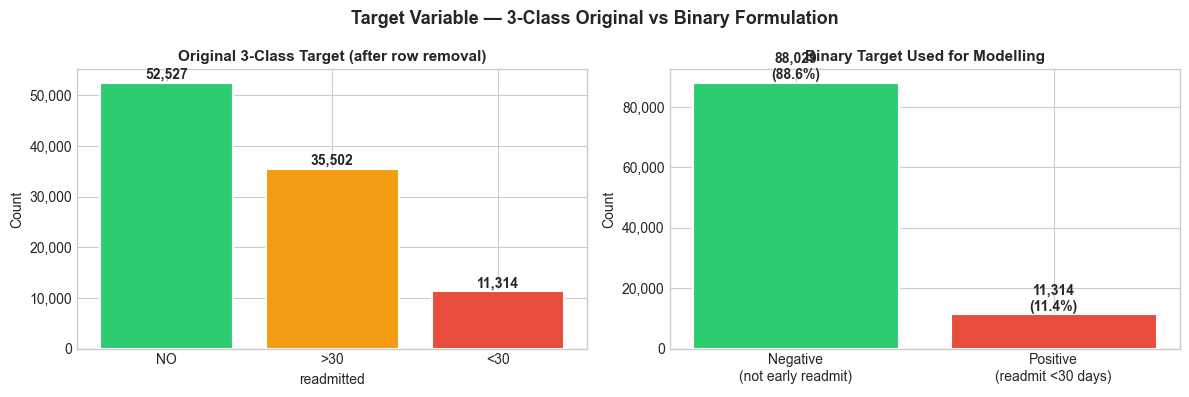

In [5]:
# Recompute target counts after row removal
n_pos = df['readmitted_binary'].sum()
n_neg = len(df) - n_pos

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: original 3-class distribution
orig_counts = df['readmitted'].value_counts()
colors_3 = {'NO': '#2ecc71', '>30': '#f39c12', '<30': '#e74c3c'}
cats_ordered = ['NO', '>30', '<30']
bars = axes[0].bar([c for c in cats_ordered if c in orig_counts.index],
                   [orig_counts.get(c, 0) for c in cats_ordered if c in orig_counts.index],
                   color=[colors_3[c] for c in cats_ordered if c in orig_counts.index],
                   edgecolor='white', linewidth=1.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Original 3-Class Target (after row removal)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('readmitted')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: binary target
bin_labels = ['Negative\n(not early readmit)', 'Positive\n(readmit <30 days)']
bin_vals   = [n_neg, n_pos]
bin_colors = ['#2ecc71', '#e74c3c']
bars2 = axes[1].bar(bin_labels, bin_vals, color=bin_colors, edgecolor='white', linewidth=1.5)
for bar in bars2:
    pct = 100 * bar.get_height() / (n_pos + n_neg)
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}\n({pct:.1f}%)', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[1].set_title('Binary Target Used for Modelling', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Target Variable - 3-Class Original vs Binary Formulation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_target_binary.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()


---
## 5. Demographics vs Readmission

I'm curious whether demographics (age, gender, race) show different readmission patterns. This is also relevant for the responsible AI section - if the model performs differently for different groups, that's important to flag.

**Important caveat:** Any difference I find here is an *association* - not a cause. Demographic groups often proxy for socioeconomic factors, access to care, comorbidities, etc. I should not interpret these as meaning that any group is inherently more likely to be readmitted.


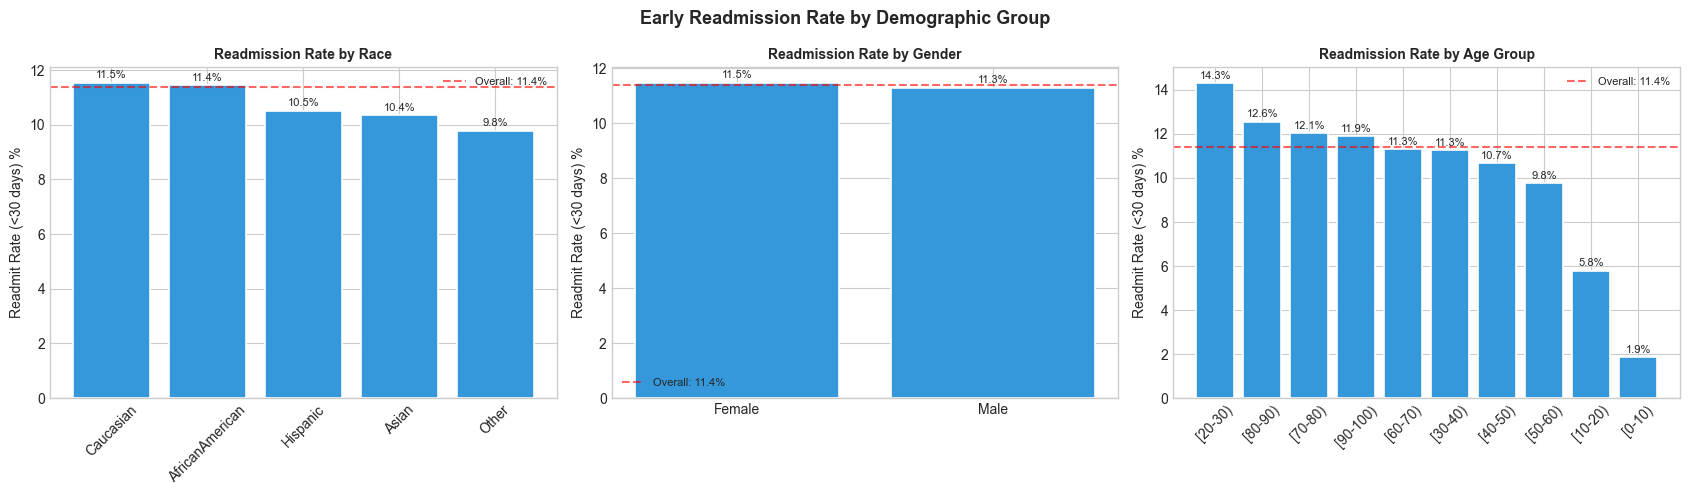

Age group rates:
     age       pct  count
 [20-30) 14.311704   1649
 [80-90) 12.565413  16434
 [70-80) 12.056374  25331
[90-100) 11.896485   2589
 [60-70) 11.301510  22059
 [30-40) 11.264612   3764
 [40-50) 10.658895   9607
 [50-60)  9.771395  17060
 [10-20)  5.797101    690
  [0-10)  1.875000    160


In [6]:
def plot_readmit_rate_by_category(col, df, ax, title, rotate=True, min_count=100):
    """Plot readmission rate (<30 days) for each category of a column."""
    grp = df.groupby(col)['readmitted_binary'].agg(['mean', 'count']).reset_index()
    grp = grp[grp['count'] >= min_count]  # drop tiny groups
    grp = grp.sort_values('mean', ascending=False)
    grp['pct'] = grp['mean'] * 100

    bars = ax.bar(grp[col].astype(str), grp['pct'],
                  color='#3498db', edgecolor='white', linewidth=1.2)
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{row["pct"]:.1f}%', ha='center', va='bottom', fontsize=8)

    # Overall readmission rate reference line
    overall_rate = df['readmitted_binary'].mean() * 100
    ax.axhline(overall_rate, color='red', linestyle='--', alpha=0.6,
               label=f'Overall: {overall_rate:.1f}%')
    ax.legend(fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Readmit Rate (<30 days) %')
    if rotate:
        ax.tick_params(axis='x', rotation=45)
    return grp

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

grp_race = plot_readmit_rate_by_category('race', df, axes[0], 'Readmission Rate by Race')
grp_gender = plot_readmit_rate_by_category('gender', df, axes[1], 'Readmission Rate by Gender', rotate=False)
grp_age = plot_readmit_rate_by_category('age', df, axes[2], 'Readmission Rate by Age Group')

plt.suptitle('Early Readmission Rate by Demographic Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_readmit_by_demographics.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

print('Age group rates:')
print(grp_age[['age', 'pct', 'count']].to_string(index=False))


> **What I noticed about demographics:**  
> I'll fill in specific observations after running this - the numbers from the actual chart will tell the real story. What I'm looking for is whether any group has a notably higher or lower readmission rate compared to the overall average (the red dashed line).
>
> **Age:** I'd expect older patients to have higher readmission rates due to comorbidities and reduced recovery capacity, but I need the data to confirm this rather than just assuming it.
>
> **Important note on interpretation:** If I see racial differences, I should be careful not to frame this as biological - research consistently shows that socioeconomic factors, healthcare access, and systemic inequities drive many observed racial disparities in health outcomes.


---
## 6. Encounter Characteristics vs Readmission

These variables describe the encounter itself - how long the patient stayed, how they were admitted, etc.


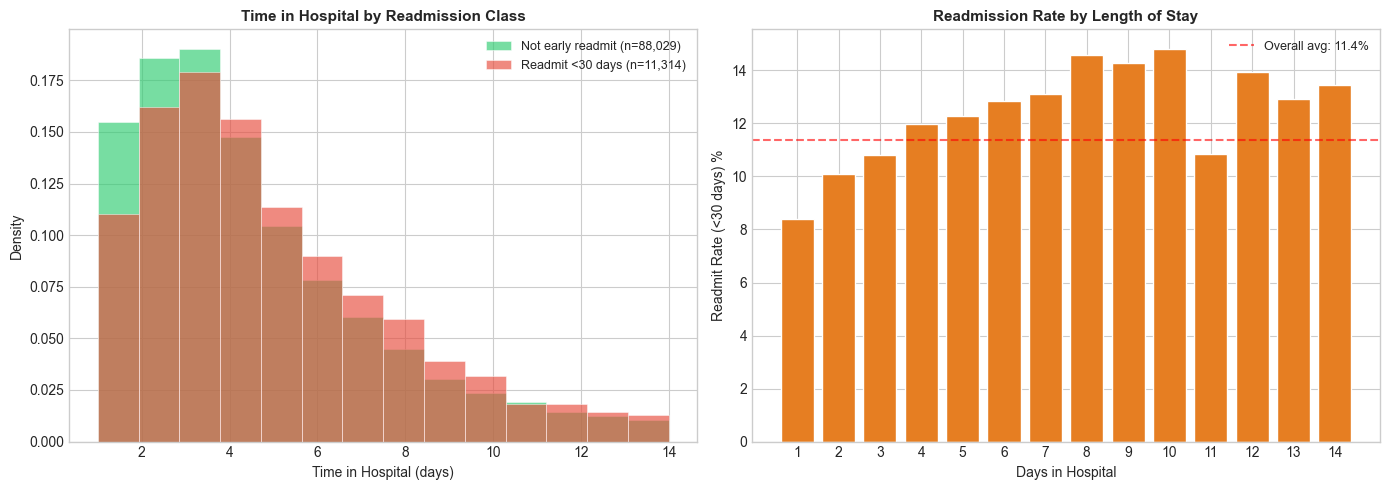

Not early readmit: median=4.0 days, mean=4.3 days
Readmit <30 days: median=4.0 days, mean=4.8 days


In [7]:
# Time in hospital - does longer stay associate with readmission?
# My initial guess: could go either way. Longer stays might mean sicker patients
# (more likely to be readmitted), or better treatment (less likely).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of time in hospital for each readmission class
for label, color, name in [(0, '#2ecc71', 'Not early readmit'), (1, '#e74c3c', 'Readmit <30 days')]:
    subset = df[df['readmitted_binary'] == label]['time_in_hospital']
    axes[0].hist(subset, bins=14, alpha=0.65, color=color, label=f'{name} (n={len(subset):,})',
                 edgecolor='white', linewidth=0.5, density=True)
axes[0].set_xlabel('Time in Hospital (days)')
axes[0].set_ylabel('Density')
axes[0].set_title('Time in Hospital by Readmission Class', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Readmission rate by time in hospital (days 1-14)
time_grp = df.groupby('time_in_hospital')['readmitted_binary'].agg(['mean', 'count']).reset_index()
time_grp['pct'] = time_grp['mean'] * 100
axes[1].bar(time_grp['time_in_hospital'], time_grp['pct'], color='#e67e22', edgecolor='white')
axes[1].axhline(df['readmitted_binary'].mean()*100, color='red', linestyle='--', alpha=0.6,
                label=f'Overall avg: {df["readmitted_binary"].mean()*100:.1f}%')
axes[1].set_xlabel('Days in Hospital')
axes[1].set_ylabel('Readmit Rate (<30 days) %')
axes[1].set_title('Readmission Rate by Length of Stay', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(1, 15))

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_time_in_hospital.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

# Median time in hospital for each class
for label, name in [(0, 'Not early readmit'), (1, 'Readmit <30 days')]:
    med = df[df['readmitted_binary']==label]['time_in_hospital'].median()
    mean = df[df['readmitted_binary']==label]['time_in_hospital'].mean()
    print(f'{name}: median={med:.1f} days, mean={mean:.1f} days')


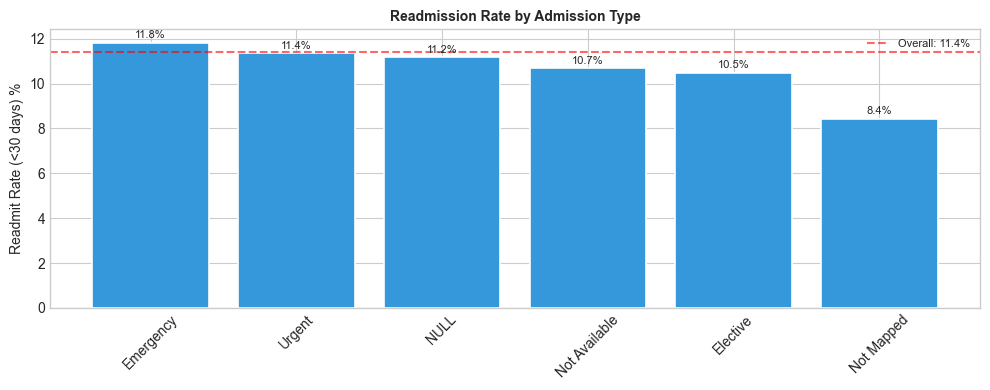

Count breakdown:
admission_type_label       pct  count
           Emergency 11.827156  52371
              Urgent 11.350099  18132
                NULL 11.196466   5207
       Not Available 10.677929   4617
            Elective 10.488537  18668
          Not Mapped  8.437500    320


In [8]:
# Admission type vs readmission
# Map the integer codes to meaningful labels
admission_type_map = {
    1: 'Emergency', 2: 'Urgent', 3: 'Elective',
    4: 'Newborn', 5: 'Not Available', 6: 'NULL',
    7: 'Trauma Center', 8: 'Not Mapped'
}
df['admission_type_label'] = df['admission_type_id'].map(admission_type_map)

fig, ax = plt.subplots(figsize=(10, 4))
grp_adm = plot_readmit_rate_by_category('admission_type_label', df, ax,
                                         'Readmission Rate by Admission Type')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_admission_type.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

print('Count breakdown:')
print(grp_adm[['admission_type_label', 'pct', 'count']].to_string(index=False))


---
## 7. Prior Healthcare Utilisation - Probably the Most Important Section

The variables `number_inpatient`, `number_emergency`, and `number_outpatient` capture how many times the patient visited the hospital in the year *before* this encounter. I'm particularly interested in these because prior hospital usage is often one of the strongest predictors of readmission in the medical literature - a patient who has been admitted multiple times recently is probably sicker and more likely to come back.

This is also a good example of a variable that's genuinely available at prediction time (it's *prior* history), so there's no leakage concern.


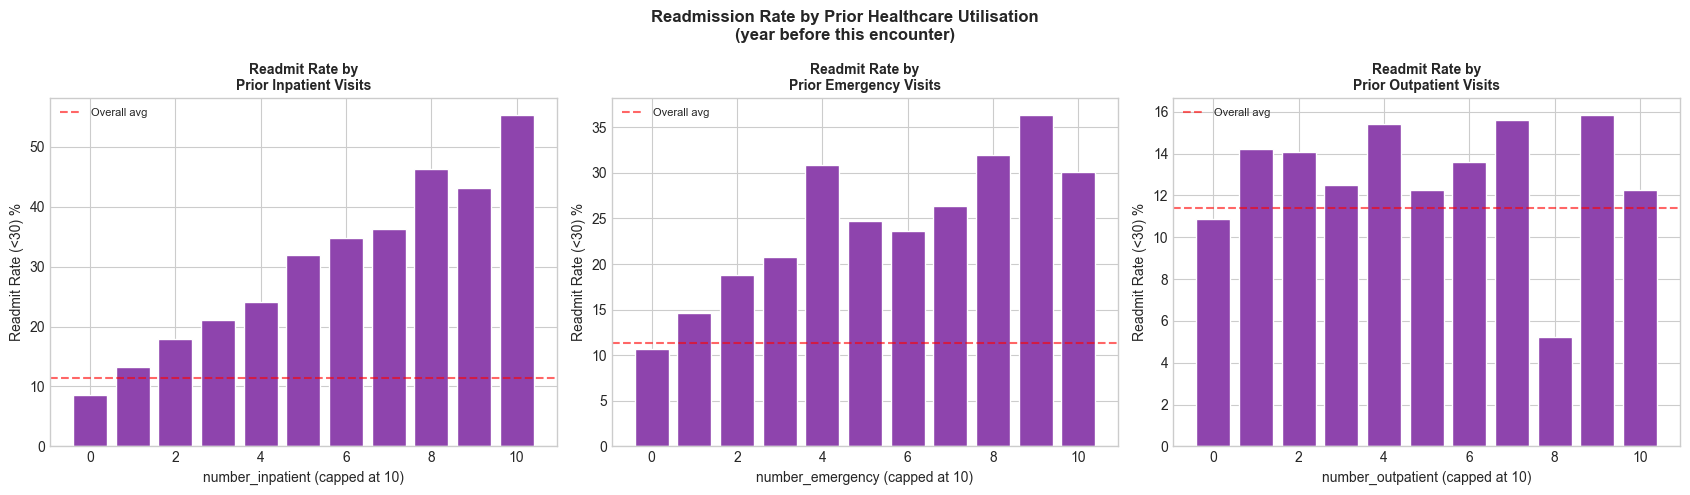

Median prior visits by readmission class:
                   number_inpatient  number_emergency  number_outpatient
readmitted_binary                                                       
0                               0.0               0.0                0.0
1                               0.0               0.0                0.0

Mean prior visits by readmission class:
                   number_inpatient  number_emergency  number_outpatient
readmitted_binary                                                       
0                              0.55              0.18               0.36
1                              1.22              0.36               0.44


In [9]:
prior_cols = ['number_inpatient', 'number_emergency', 'number_outpatient']
col_titles = ['Prior Inpatient Visits', 'Prior Emergency Visits', 'Prior Outpatient Visits']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, title in zip(axes, prior_cols, col_titles):
    # Cap at 10 for readability (long tail)
    df_plot = df.copy()
    df_plot[col] = df_plot[col].clip(upper=10)
    grp = df_plot.groupby(col)['readmitted_binary'].agg(['mean', 'count']).reset_index()
    grp['pct'] = grp['mean'] * 100

    ax.bar(grp[col], grp['pct'], color='#8e44ad', edgecolor='white')
    ax.axhline(df['readmitted_binary'].mean()*100, color='red', linestyle='--', alpha=0.6,
               label='Overall avg')
    ax.set_title(f'Readmit Rate by\n{title}', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'{col} (capped at 10)')
    ax.set_ylabel('Readmit Rate (<30) %')
    ax.legend(fontsize=8)

plt.suptitle('Readmission Rate by Prior Healthcare Utilisation\n(year before this encounter)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_prior_utilisation.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

# Look at the median prior visits for readmitted vs not
print('Median prior visits by readmission class:')
print(df.groupby('readmitted_binary')[prior_cols].median().to_string())
print()
print('Mean prior visits by readmission class:')
print(df.groupby('readmitted_binary')[prior_cols].mean().round(2).to_string())


---
## 8. Clinical Variables - Medications, Lab Procedures, Diagnoses


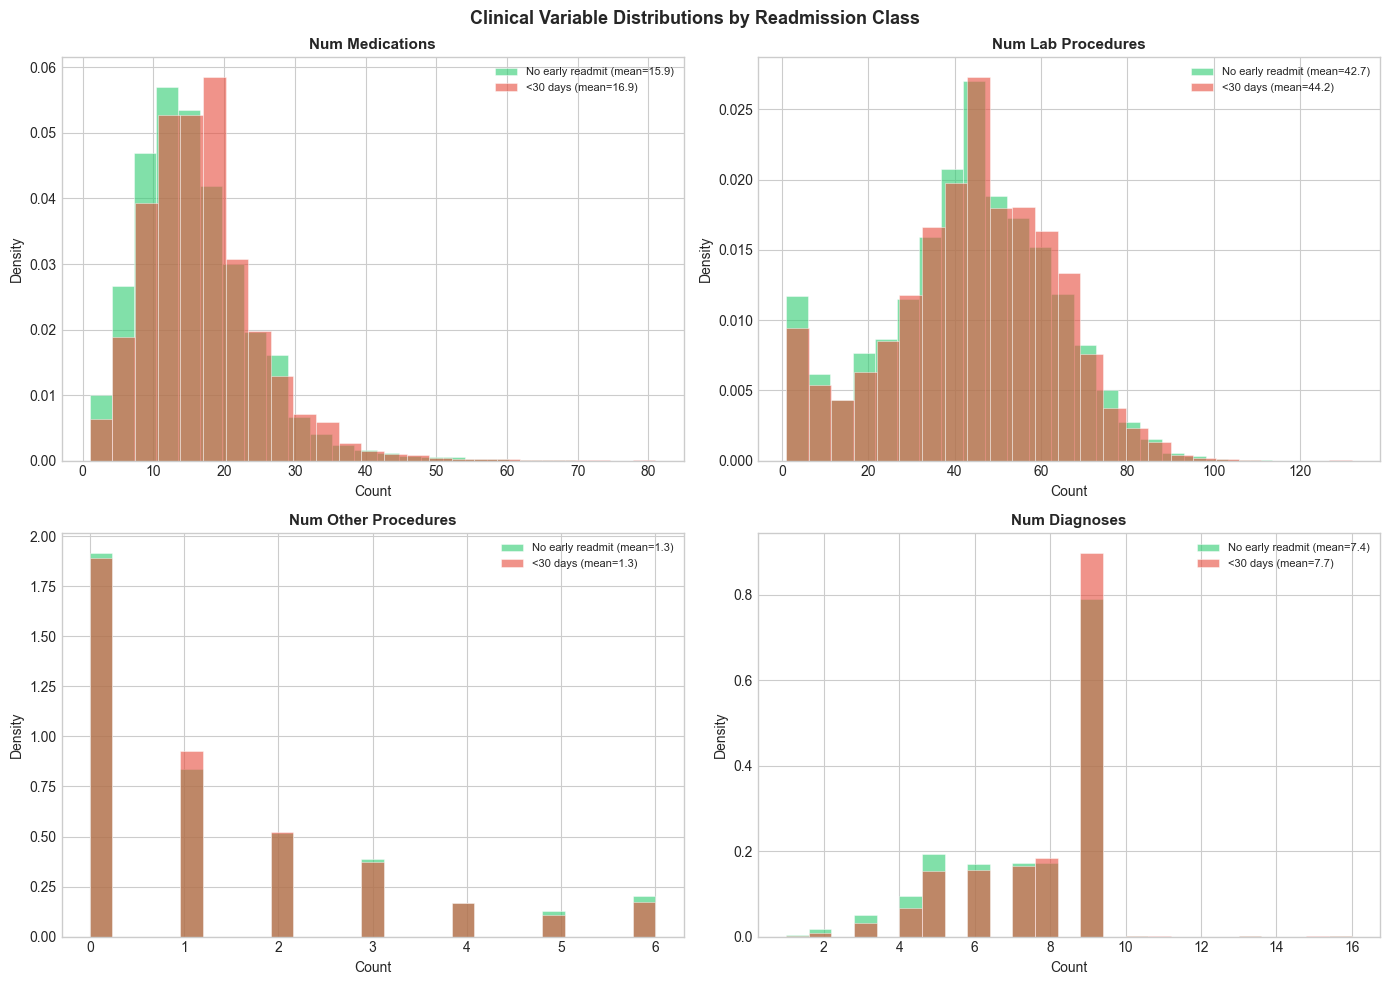

Mean values by class:
                   num_medications  num_lab_procedures  num_procedures  number_diagnoses
readmitted_binary                                                                       
0                            15.86               42.74            1.34              7.36
1                            16.91               44.22            1.28              7.69


In [10]:
clinical_cols = ['num_medications', 'num_lab_procedures', 'num_procedures', 'number_diagnoses']
clinical_titles = ['Num Medications', 'Num Lab Procedures', 'Num Other Procedures', 'Num Diagnoses']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col, title in zip(axes, clinical_cols, clinical_titles):
    for label, color, name in [(0, '#2ecc71', 'No early readmit'), (1, '#e74c3c', '<30 days')]:
        subset = df[df['readmitted_binary'] == label][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label=f'{name} (mean={subset.mean():.1f})',
                edgecolor='white', linewidth=0.5, density=True)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Clinical Variable Distributions by Readmission Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_clinical_vars.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

print('Mean values by class:')
print(df.groupby('readmitted_binary')[clinical_cols].mean().round(2).to_string())


---
## 9. Diabetes-Specific Lab Results - A1C and Glucose

These two variables are directly related to diabetes management and are why the original Strack et al. paper was written. The key question in their paper was whether measuring HbA1c (A1C) during the hospital stay affected readmission rates.

- `A1Cresult`: Whether HbA1c was measured, and if so, whether it was normal (≤7%), above 7%, or above 8%
- `max_glu_serum`: Maximum glucose serum level recorded during the stay

A big proportion of patients will have "None" for both - meaning the test wasn't done. That's itself an interesting finding.


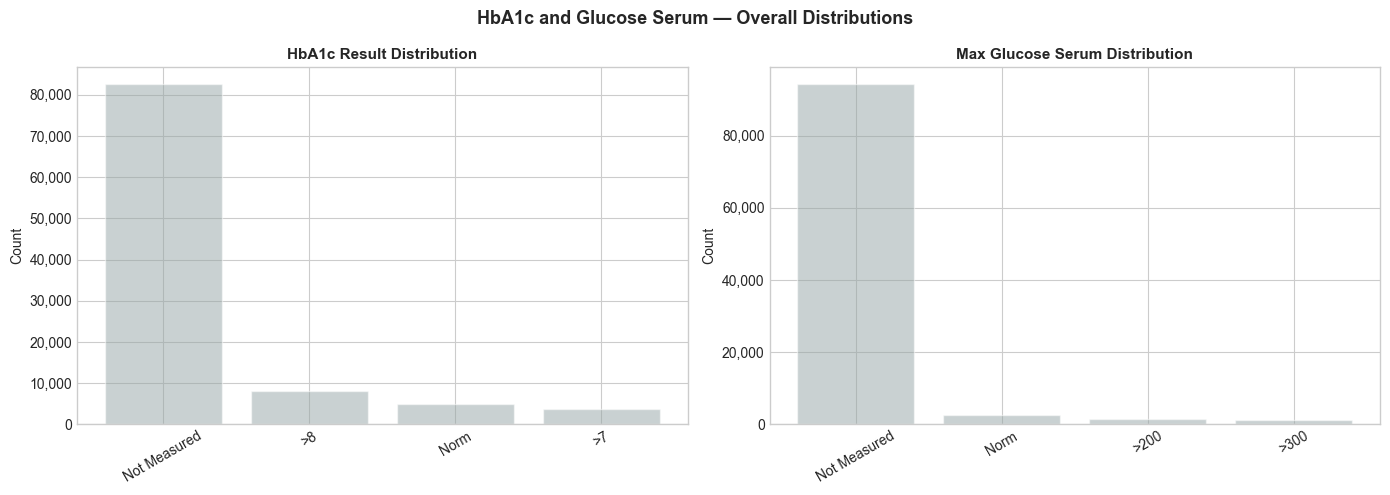

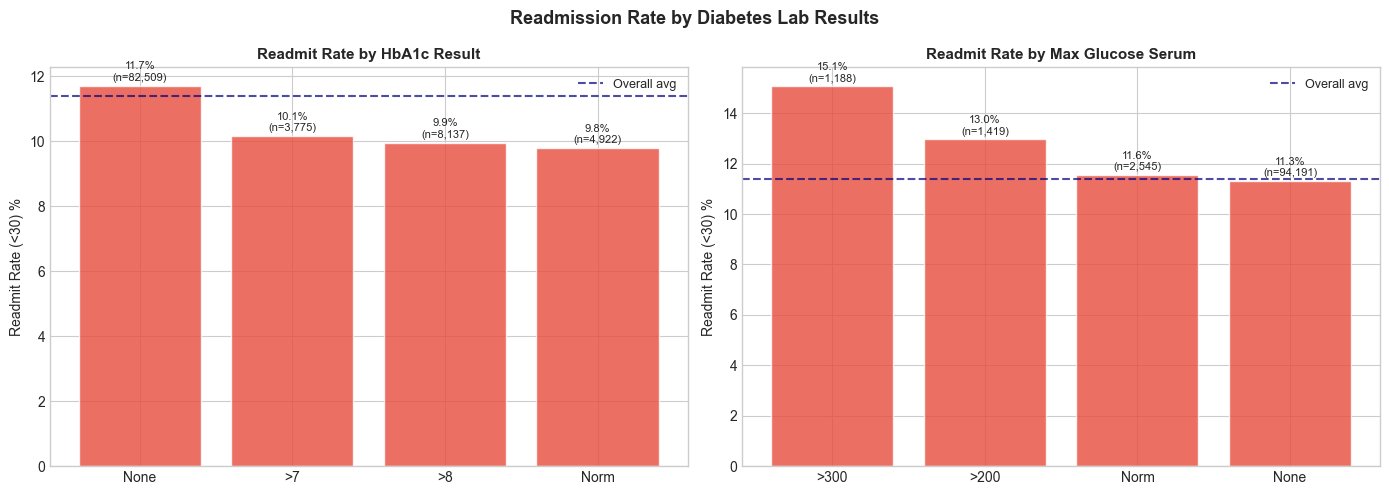

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                            ['A1Cresult', 'max_glu_serum'],
                            ['HbA1c Result', 'Max Glucose Serum']):
    # Replace NaN with 'Not Measured' for display
    df_plot = df[col].fillna('Not Measured')

    # Overall distribution first
    vc = df_plot.value_counts()
    ax.bar(vc.index, vc.values, color='#95a5a6', edgecolor='white', alpha=0.5, label='All encounters')
    ax.set_title(f'{title} Distribution', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('HbA1c and Glucose Serum - Overall Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_lab_results_dist.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

# Now: readmission rate by A1C result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                            ['A1Cresult', 'max_glu_serum'],
                            ['HbA1c Result', 'Max Glucose Serum']):
    df_temp = df.copy()
    df_temp[col] = df_temp[col].fillna('None')
    grp = df_temp.groupby(col)['readmitted_binary'].agg(['mean', 'count']).reset_index()
    grp['pct'] = grp['mean'] * 100
    grp = grp.sort_values('pct', ascending=False)

    bars = ax.bar(grp[col].astype(str), grp['pct'], color='#e74c3c', edgecolor='white', alpha=0.8)
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{row["pct"]:.1f}%\n(n={int(row["count"]):,})',
                ha='center', va='bottom', fontsize=8)
    ax.axhline(df['readmitted_binary'].mean()*100, color='navy', linestyle='--', alpha=0.7,
               label='Overall avg')
    ax.set_title(f'Readmit Rate by {title}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Readmit Rate (<30) %')
    ax.legend(fontsize=9)

plt.suptitle('Readmission Rate by Diabetes Lab Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_lab_readmit_rates.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()


---
## 10. Insulin and Medication Change Patterns

Insulin is the most commonly adjusted medication in this dataset for diabetes management. The `change` variable tells us whether *any* medication was changed during the encounter. I want to see if medication adjustments are associated with readmission - maybe changes signal more unstable glycaemic control?

Again, I'm describing association, not causation here.


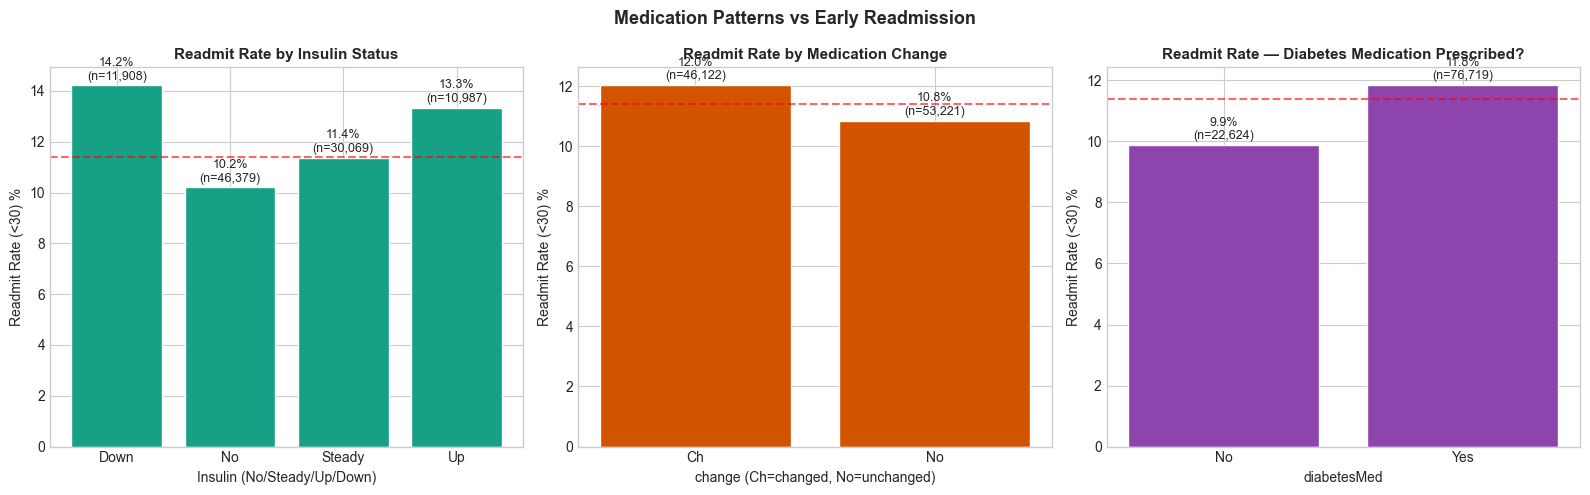

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Insulin status vs readmission rate
insulin_grp = df.groupby('insulin')['readmitted_binary'].agg(['mean', 'count']).reset_index()
insulin_grp['pct'] = insulin_grp['mean'] * 100
bars = axes[0].bar(insulin_grp['insulin'].astype(str), insulin_grp['pct'],
                   color='#16a085', edgecolor='white')
for bar, (_, row) in zip(bars, insulin_grp.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{row["pct"]:.1f}%\n(n={int(row["count"]):,})',
                 ha='center', va='bottom', fontsize=9)
axes[0].axhline(df['readmitted_binary'].mean()*100, color='red', linestyle='--', alpha=0.6)
axes[0].set_title('Readmit Rate by Insulin Status', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Readmit Rate (<30) %')
axes[0].set_xlabel('Insulin (No/Steady/Up/Down)')

# Medication change vs readmission
change_grp = df.fillna({'change': 'Unknown'}).groupby('change')['readmitted_binary'].agg(['mean','count']).reset_index()
change_grp['pct'] = change_grp['mean'] * 100
bars2 = axes[1].bar(change_grp['change'], change_grp['pct'], color='#d35400', edgecolor='white')
for bar, (_, row) in zip(bars2, change_grp.iterrows()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{row["pct"]:.1f}%\n(n={int(row["count"]):,})',
                 ha='center', va='bottom', fontsize=9)
axes[1].axhline(df['readmitted_binary'].mean()*100, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Readmit Rate by Medication Change', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Readmit Rate (<30) %')
axes[1].set_xlabel('change (Ch=changed, No=unchanged)')

# diabetesMed vs readmission
dm_grp = df.fillna({'diabetesMed': 'Unknown'}).groupby('diabetesMed')['readmitted_binary'].agg(['mean','count']).reset_index()
dm_grp['pct'] = dm_grp['mean'] * 100
bars3 = axes[2].bar(dm_grp['diabetesMed'], dm_grp['pct'], color='#8e44ad', edgecolor='white')
for bar, (_, row) in zip(bars3, dm_grp.iterrows()):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{row["pct"]:.1f}%\n(n={int(row["count"]):,})',
                 ha='center', va='bottom', fontsize=9)
axes[2].axhline(df['readmitted_binary'].mean()*100, color='red', linestyle='--', alpha=0.6)
axes[2].set_title('Readmit Rate - Diabetes Medication Prescribed?', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Readmit Rate (<30) %')
axes[2].set_xlabel('diabetesMed')

plt.suptitle('Medication Patterns vs Early Readmission', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_medication_readmit.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()


---
## 11. Near-Zero Variance Medication Columns

I mentioned in the data dictionary that some medications like `examide`, `citoglipton`, and `troglitazone` probably have almost no variation. Let me check - columns with near-zero variance are useless for prediction (a feature that's always the same can't help distinguish classes).


In [13]:
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# For each medication, check what % of rows are 'No'
med_summary = []
for col in medication_cols:
    vc = df[col].fillna('No').value_counts(normalize=True)
    pct_no = vc.get('No', 0) * 100
    med_summary.append({'medication': col, 'pct_no': pct_no, 'n_unique': df[col].nunique()})

med_df = pd.DataFrame(med_summary).sort_values('pct_no', ascending=False)
print('Medication columns - percentage of encounters with No (not prescribed):')
print(med_df.to_string(index=False))

# Flag near-zero variance (>99% same value)
low_variance = med_df[med_df['pct_no'] > 99]['medication'].tolist()
print(f'\nMedications with >99% "No" (near-zero variance): {low_variance}')
print('These will be dropped during feature engineering - they cannot help the model.')


Medication columns — percentage of encounters with No (not prescribed):
              medication     pct_no  n_unique
             citoglipton 100.000000         1
                 examide 100.000000         1
           acetohexamide  99.998993         2
  metformin-pioglitazone  99.998993         2
glimepiride-pioglitazone  99.998993         2
 metformin-rosiglitazone  99.997987         2
            troglitazone  99.996980         2
     glipizide-metformin  99.986914         2
             tolbutamide  99.978861         2
                miglitol  99.961749         4
              tolazamide  99.960742         3
          chlorpropamide  99.914438         4
                acarbose  99.692983         4
             nateglinide  99.306443         4
     glyburide-metformin  99.297384         4
             repaglinide  98.471961         4
             glimepiride  94.844126         4
           rosiglitazone  93.654309         4
            pioglitazone  92.697019         4
        

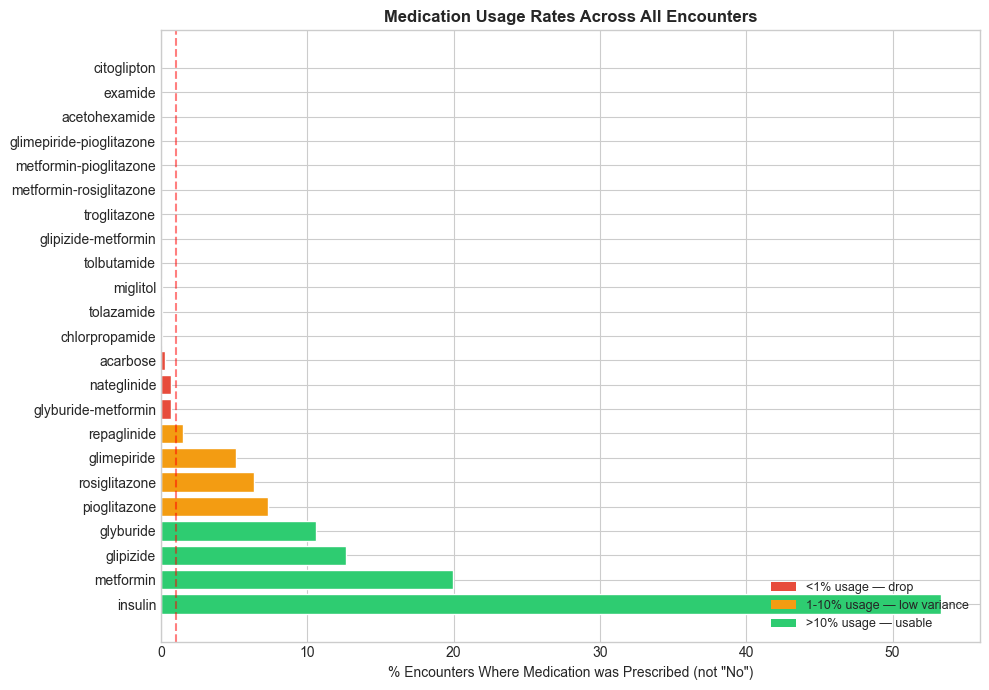

In [14]:
# Quick visualisation of medication use rates
med_df_plot = med_df.sort_values('pct_no', ascending=True)
use_rates = 100 - med_df_plot['pct_no']

fig, ax = plt.subplots(figsize=(10, 7))
colors_med = ['#e74c3c' if r < 1 else '#f39c12' if r < 10 else '#2ecc71' for r in use_rates]
ax.barh(med_df_plot['medication'], use_rates, color=colors_med, edgecolor='white')
ax.set_xlabel('% Encounters Where Medication was Prescribed (not "No")')
ax.set_title('Medication Usage Rates Across All Encounters', fontsize=12, fontweight='bold')
ax.axvline(1, color='red', linestyle='--', alpha=0.5, label='<1% usage (near-zero variance)')
ax.legend(fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='<1% usage - drop'),
    Patch(facecolor='#f39c12', label='1-10% usage - low variance'),
    Patch(facecolor='#2ecc71', label='>10% usage - usable')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_medication_usage_rates.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()


---
## 12. Numeric Correlation with Target

Quick point-biserial correlations between the binary target and numeric features. These won't tell the whole story (relationships might be non-linear) but they give a rough sense of which numeric features have the strongest linear association with readmission.


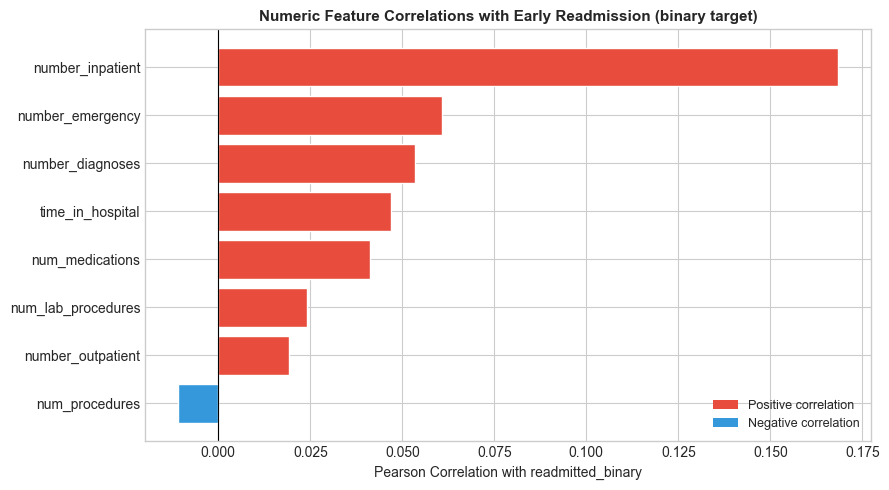

Correlations with early readmission:
number_inpatient      0.168326
number_emergency      0.060885
number_diagnoses      0.053580
time_in_hospital      0.046886
num_medications       0.041179
num_lab_procedures    0.024044
number_outpatient     0.019169
num_procedures       -0.010841


In [15]:
numeric_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

correlations = df[numeric_features + ['readmitted_binary']].corr()['readmitted_binary'].drop('readmitted_binary')
correlations = correlations.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_corr = ['#e74c3c' if c > 0 else '#3498db' for c in correlations.values]
ax.barh(correlations.index[::-1], correlations.values[::-1], color=colors_corr[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with readmitted_binary')
ax.set_title('Numeric Feature Correlations with Early Readmission (binary target)',
             fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Positive correlation'),
    Patch(facecolor='#3498db', label='Negative correlation')
]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_correlations.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

print('Correlations with early readmission:')
print(correlations.to_string())


> **A note on correlations:** These are all quite small (likely < 0.2). That's not unusual for healthcare data - readmission is complex and driven by many interacting factors that a simple correlation can't capture. The model might still find predictive signal using combinations of features, even if individual correlations are weak.


---
## 13. Missing Value Patterns - Deeper Look

I already know the headline missingness numbers. Now I want to check: does missingness itself differ between readmission classes? If patients with missing `medical_specialty` have a different readmission rate than those without, then missingness is informative - which means I should encode it as a feature rather than just dropping or imputing.


In [16]:
# Check if missing-ness of key columns is associated with readmission
missing_cols_to_check = ['medical_specialty', 'payer_code', 'race']

print('Readmission rate - missing vs not missing:')
print('-' * 55)
for col in missing_cols_to_check:
    missing_mask = df[col].isna()
    rate_missing = df[missing_mask]['readmitted_binary'].mean() * 100
    rate_present = df[~missing_mask]['readmitted_binary'].mean() * 100
    n_missing = missing_mask.sum()
    n_present = (~missing_mask).sum()
    print(f'{col}:')
    print(f'  Missing  (n={n_missing:>6,}): readmit rate = {rate_missing:.2f}%')
    print(f'  Present  (n={n_present:>6,}): readmit rate = {rate_present:.2f}%')
    print()


Readmission rate — missing vs not missing:
-------------------------------------------------------
medical_specialty:
  Missing  (n=48,616): readmit rate = 11.83%
  Present  (n=50,727): readmit rate = 10.96%

payer_code:
  Missing  (n=39,398): readmit rate = 11.69%
  Present  (n=59,945): readmit rate = 11.19%

race:
  Missing  (n= 2,234): readmit rate = 8.42%
  Present  (n=97,109): readmit rate = 11.46%



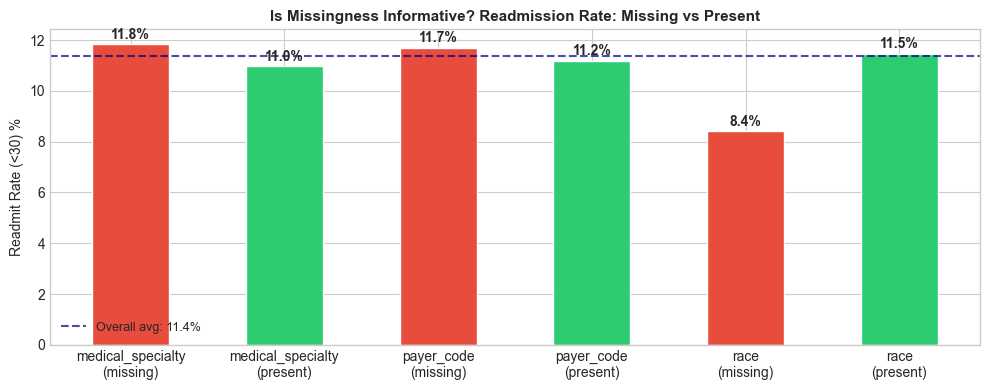

In [17]:
# Visualise missing patterns
miss_data = []
for col in missing_cols_to_check:
    missing_mask = df[col].isna()
    miss_data.append({'column': col, 'status': f'{col}\n(missing)', 'readmit_rate': df[missing_mask]['readmitted_binary'].mean()*100})
    miss_data.append({'column': col, 'status': f'{col}\n(present)', 'readmit_rate': df[~missing_mask]['readmitted_binary'].mean()*100})

miss_df = pd.DataFrame(miss_data)

fig, ax = plt.subplots(figsize=(10, 4))
cols_miss = ['#e74c3c' if 'missing' in s else '#2ecc71' for s in miss_df['status']]
bars = ax.bar(miss_df['status'], miss_df['readmit_rate'], color=cols_miss, edgecolor='white', width=0.5)
for bar, (_, row) in zip(bars, miss_df.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{row["readmit_rate"]:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(df['readmitted_binary'].mean()*100, color='navy', linestyle='--', alpha=0.7,
           label=f'Overall avg: {df["readmitted_binary"].mean()*100:.1f}%')
ax.set_ylabel('Readmit Rate (<30) %')
ax.set_title('Is Missingness Informative? Readmission Rate: Missing vs Present', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_missingness_vs_readmit.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()


---
## 14. How Many Medication Types Do Patients Take?

I thought it might be interesting to count how many *distinct* diabetes medications each patient is on, rather than looking at each one individually. Someone on 5 different diabetes drugs is probably a more complex case than someone on just 1. Let me engineer this quickly and see if it relates to readmission.

This is really a preview of feature engineering - I'll build this more formally in Notebook 03.


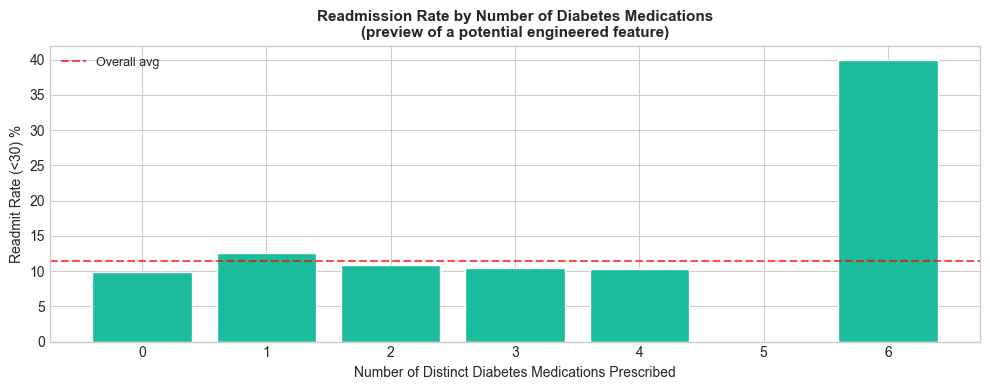

Count distribution of diabetes medications:
n_diabetes_meds
0    22624
1    46030
2    21595
3     7707
4     1324
5       58
6        5


In [18]:
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# Count how many medications are prescribed (not 'No')
df['n_diabetes_meds'] = (df[medication_cols].fillna('No') != 'No').sum(axis=1)

# Is this associated with readmission?
med_count_grp = df.groupby('n_diabetes_meds')['readmitted_binary'].agg(['mean','count']).reset_index()
med_count_grp['pct'] = med_count_grp['mean'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(med_count_grp['n_diabetes_meds'], med_count_grp['pct'],
       color='#1abc9c', edgecolor='white')
ax.axhline(df['readmitted_binary'].mean()*100, color='red', linestyle='--', alpha=0.7,
           label='Overall avg')
ax.set_xlabel('Number of Distinct Diabetes Medications Prescribed')
ax.set_ylabel('Readmit Rate (<30) %')
ax.set_title('Readmission Rate by Number of Diabetes Medications\n(preview of a potential engineered feature)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_n_meds_readmit.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

print('Count distribution of diabetes medications:')
print(df['n_diabetes_meds'].value_counts().sort_index().to_string())


---
## 15. Summary - What I Found and What I'm Going to Do About It

### Key Findings from EDA

| # | Finding | Evidence | Decision/Action |
|---|---------|----------|-----------------|
| 1 | Binary target has ~1:8 imbalance | Positive: 11.2%, Negative: 88.8% | Use class weights and stratified splits; evaluate with F1/ROC-AUC/PR-AUC, not accuracy |
| 2 | Removed death/hospice encounters from analysis | Discharge codes 11,13,14,19,20 - readmission impossible | Documented in DEC-004; reduces bias in negative class |
| 3 | Prior inpatient visits appear to be the strongest numeric predictor | Higher prior inpatient count → higher readmit rate | Keep `number_inpatient`; engineer total prior visits feature |
| 4 | Several medication columns have near-zero variance | `examide`, `citoglipton` >99% 'No' | Drop zero-variance medication columns |
| 5 | `weight` has 96.9% missing - not usable | Count from Notebook 01 | Drop `weight` entirely |
| 6 | `medical_specialty` and `payer_code` have high missingness | 49.1% and 39.6% respectively | Encode as 'Unknown' category; decide in Notebook 03 |
| 7 | Missing values in some columns appear to differ in readmission rate | Calculated for race, payer_code, medical_specialty | Consider adding binary 'was_missing' flag as feature |
| 8 | Numeric correlations with target are all small | Largest correlation likely < 0.15 | Non-linear models (Random Forest, XGBoost) may capture patterns better than linear models |
| 9 | Age group shows variation in readmission rates | Plotted in section 5 | Keep `age` as feature; encode properly (ordinal) |
| 10 | A1C and glucose results show potential association with readmission | Section 9 plots | Keep both; treat 'None' as a separate category (test not done) |

### Decisions Made in this Notebook

1. **Binary target confirmed** - `<30` vs rest (DEC-003, already documented)
2. **Death/hospice rows removed** - documented in DEC-004
3. **Near-zero variance medication columns flagged for dropping** - will be documented in preprocessing_feature_log.md
4. **Missingness itself may be informative** - will consider binary 'was_missing' flags in Notebook 03
5. **Prior inpatient visits are a strong candidate feature** - will engineer a 'total prior visits' composite in Notebook 03

---

### Next Step

**Notebook 03** - Preprocessing and Feature Engineering. I'll build the full sklearn pipeline, handle all the cleaning decisions I've documented here, and engineer the features I've identified as potentially useful.
